# Assignment 7: Dimensionality Reduction and Model Evaluation (With and Without PCA)

**ICS1512 - Machine Learning Algorithms Laboratory**
**Dataset:** Wisconsin Diagnostic Breast Cancer (WDBC)

## Aim

To study the effect of Principal Component Analysis (PCA) on the performance of 10 different
machine learning classifiers, by comparing their performance with and without PCA on the
Wisconsin Diagnostic Breast Cancer (WDBC) dataset.

## Objective

- Train and evaluate 10 classifiers (SVM, Naive Bayes, KNN, Logistic Regression, Decision Tree,
  Random Forest, AdaBoost, Gradient Boosting, XGBoost, Stacking) on the WDBC dataset.
- Perform hyperparameter tuning using GridSearchCV for every model.
- Evaluate every model using 5-fold Stratified Cross-Validation, in two settings: **No-PCA**
  (original 30 features) and **With-PCA** (reduced feature space, ~95% variance retained).
- Compare No-PCA vs With-PCA results and answer the observation questions using the actual
  results obtained.

## Dataset Description

The **Wisconsin Diagnostic Breast Cancer (WDBC)** dataset (`wdbc.data`, `wdbc.names`) is used.

- Number of samples: 569
- Number of features: 30 numeric features computed from digitized images of a fine needle
  aspirate (FNA) of a breast mass (mean, standard error and "worst" value of 10 nuclear
  characteristics).
- Target: Diagnosis — **M = Malignant**, **B = Benign**
- The first column is an ID number (not a feature) and is dropped before modelling.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, StackingClassifier)
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# WDBC data has no header row. Column names as per wdbc.names.
base_features = ["radius", "texture", "perimeter", "area", "smoothness",
                  "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension"]
columns = ["id", "diagnosis"]
for stat in ["mean", "se", "worst"]:
    columns += [f"{f}_{stat}" for f in base_features]

df = pd.read_csv("wdbc.data", header=None, names=columns)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print("Number of samples :", df.shape[0])
print("Number of columns (incl. id, diagnosis):", df.shape[1])
print("Number of features to be used for modelling:", df.shape[1] - 2)
print()
print("Class distribution:")
print(df["diagnosis"].value_counts())
print()
print("Missing values per column (total):", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print()
print("Data types:")
print(df.dtypes.value_counts())

Number of samples : 569
Number of columns (incl. id, diagnosis): 32
Number of features to be used for modelling: 30

Class distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

Missing values per column (total): 0
Duplicate rows: 0

Data types:
float64    30
int64       1
str         1
Name: count, dtype: int64


In [4]:
# Drop the ID column - it is not a feature
data = df.drop(columns=["id"]).copy()

# Encode target: B = 0, M = 1
le = LabelEncoder()
data["diagnosis"] = le.fit_transform(data["diagnosis"])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X = data.drop(columns=["diagnosis"])
y = data["diagnosis"]

print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nMissing values after preprocessing:", X.isnull().sum().sum())

Label mapping: {'B': np.int64(0), 'M': np.int64(1)}

Feature matrix shape: (569, 30)
Target vector shape: (569,)

Missing values after preprocessing: 0


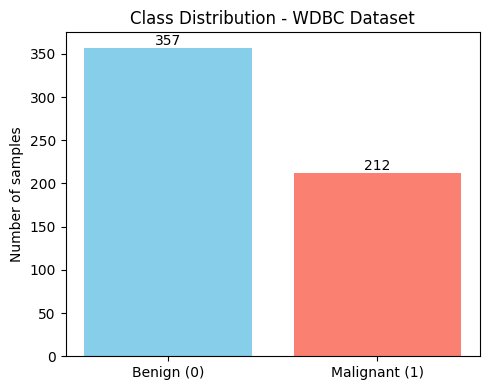

Benign  : 357 (62.7%)
Malignant: 212 (37.3%)


In [5]:
counts = y.value_counts().sort_index()
plt.figure(figsize=(5, 4))
plt.bar(["Benign (0)", "Malignant (1)"], counts.values, color=["skyblue", "salmon"])
plt.ylabel("Number of samples")
plt.title("Class Distribution - WDBC Dataset")
for i, v in enumerate(counts.values):
    plt.text(i, v + 3, str(v), ha="center")
plt.tight_layout()
plt.show()

print("Benign  :", counts[0], f"({counts[0]/len(y)*100:.1f}%)")
print("Malignant:", counts[1], f"({counts[1]/len(y)*100:.1f}%)")

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Training set size:", X_train.shape)
print("Test set size    :", X_test.shape)
print("Training class distribution:\n", y_train.value_counts())
print("Test class distribution:\n", y_test.value_counts())

Training set size: (455, 30)
Test set size    : (114, 30)
Training class distribution:
 diagnosis
0    285
1    170
Name: count, dtype: int64
Test class distribution:
 diagnosis
0    72
1    42
Name: count, dtype: int64


In [7]:
# Fit PCA only on standardized TRAINING data to avoid data leakage
scaler_for_pca = StandardScaler()
X_train_scaled = scaler_for_pca.fit_transform(X_train)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

cum_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cum_variance >= 0.95) + 1

print("Original number of features :", X_train.shape[1])
print("Components needed for 95% variance:", n_components_95)
print(f"Cumulative explained variance with {n_components_95} components: {cum_variance[n_components_95-1]*100:.2f}%")

Original number of features : 30
Components needed for 95% variance: 10
Cumulative explained variance with 10 components: 95.21%


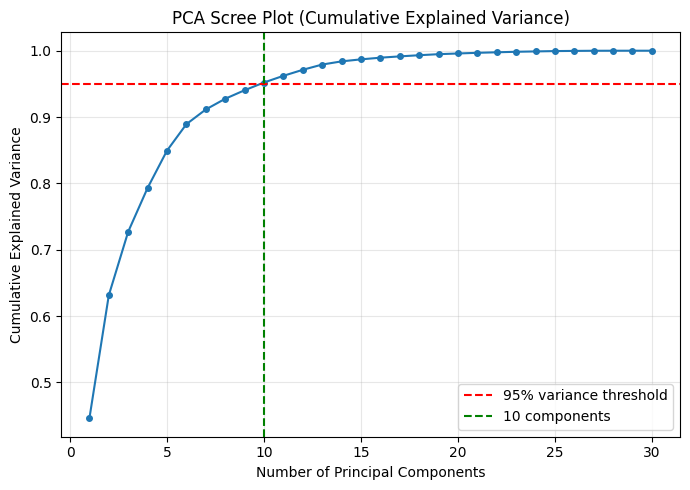

Why PCA is used: The 30 original features are correlated (many describe related nuclear
shape properties). PCA compresses them into 10 uncorrelated components
that still retain about 95% of the information, which can reduce noise and training time.


In [8]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(cum_variance)+1), cum_variance, marker="o", markersize=4)
plt.axhline(y=0.95, color="red", linestyle="--", label="95% variance threshold")
plt.axvline(x=n_components_95, color="green", linestyle="--", label=f"{n_components_95} components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot (Cumulative Explained Variance)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Why PCA is used: The 30 original features are correlated (many describe related nuclear")
print("shape properties). PCA compresses them into", n_components_95, "uncorrelated components")
print("that still retain about 95% of the information, which can reduce noise and training time.")

In [9]:
N_COMPONENTS = n_components_95

models = {
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
    "Stacking": StackingClassifier(
        estimators=[
            ("svm", SVC(probability=True, random_state=RANDOM_STATE)),
            ("nb", GaussianNB()),
            ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE))
        ],
        final_estimator=LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
        cv=5)
}

print("Models defined:", list(models.keys()))

Models defined: ['SVM', 'Naive Bayes', 'KNN', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost', 'Stacking']


In [10]:
param_grids = {
    "SVM": [
        {"model__kernel": ["linear"], "model__C": [0.1, 1, 10]},
        {"model__kernel": ["rbf"], "model__C": [0.1, 1, 10], "model__gamma": ["scale", "auto"]}
    ],
    "Naive Bayes": {
        "model__var_smoothing": [1e-9, 1e-8, 1e-7]
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan"]
    },
    "Logistic Regression": {
        "model__C": [0.1, 1, 10]
    },
    "Decision Tree": {
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [3, 5, 10]
    },
    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10],
        "model__max_features": ["sqrt", "log2"]
    },
    "AdaBoost": {
        "model__n_estimators": [50, 100],
        "model__learning_rate": [0.5, 1.0]
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3]
    },
    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 5]
    },
    "Stacking": {
        "model__final_estimator__C": [0.1, 1, 10]
    }
}

print("Hyperparameter grids defined for all", len(param_grids), "models.")

Hyperparameter grids defined for all 10 models.


In [11]:
def build_pipeline(model, use_pca):
    steps = [("scaler", StandardScaler())]
    if use_pca:
        steps.append(("pca", PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)))
    steps.append(("model", model))
    return Pipeline(steps)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {}   # key: (model_name, setting) -> dict of results

for name, model in models.items():
    for use_pca in [False, True]:
        setting = "With-PCA" if use_pca else "No-PCA"
        pipe = build_pipeline(model, use_pca)
        grid = GridSearchCV(pipe, param_grids[name], cv=cv5, scoring="accuracy", n_jobs=-1)
        grid.fit(X_train, y_train)

        best_idx = grid.best_index_
        fold_scores = [grid.cv_results_[f"split{i}_test_score"][best_idx] for i in range(5)]

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)
        if hasattr(best_model, "predict_proba"):
            y_score = best_model.predict_proba(X_test)[:, 1]
        else:
            y_score = best_model.decision_function(X_test)

        results[(name, setting)] = {
            "best_params": grid.best_params_,
            "fold_scores": fold_scores,
            "cv_mean": np.mean(fold_scores),
            "cv_std": np.std(fold_scores),
            "test_accuracy": accuracy_score(y_test, y_pred),
            "test_precision": precision_score(y_test, y_pred),
            "test_recall": recall_score(y_test, y_pred),
            "test_f1": f1_score(y_test, y_pred),
            "test_roc_auc": roc_auc_score(y_test, y_score),
            "y_pred": y_pred,
            "y_score": y_score,
            "model": best_model
        }
        print(f"{name:22s} | {setting:9s} | CV Acc: {np.mean(fold_scores):.4f} | Test Acc: {results[(name, setting)]['test_accuracy']:.4f}")

print("\nAll 10 models trained and evaluated in both settings.")

SVM                    | No-PCA    | CV Acc: 0.9758 | Test Acc: 0.9737


SVM                    | With-PCA  | CV Acc: 0.9736 | Test Acc: 0.9825
Naive Bayes            | No-PCA    | CV Acc: 0.9385 | Test Acc: 0.9211


Naive Bayes            | With-PCA  | CV Acc: 0.9165 | Test Acc: 0.8947


KNN                    | No-PCA    | CV Acc: 0.9758 | Test Acc: 0.9649


KNN                    | With-PCA  | CV Acc: 0.9714 | Test Acc: 0.9474
Logistic Regression    | No-PCA    | CV Acc: 0.9736 | Test Acc: 0.9649


...

Gradient Boosting      | With-PCA  | CV Acc: 0.9538 | Test Acc: 0.9561


XGBoost                | No-PCA    | CV Acc: 0.9714 | Test Acc: 0.9649


XGBoost                | With-PCA  | CV Acc: 0.9736 | Test Acc: 0.9737


Stacking               | No-PCA    | CV Acc: 0.9736 | Test Acc: 0.9825


Stacking               | With-PCA  | CV Acc: 0.9714 | Test Acc: 0.9737

All 10 models trained and evaluated in both settings.


In [12]:
comparison_rows = []
for name in models.keys():
    row = {"Model": name}
    for setting in ["No-PCA", "With-PCA"]:
        r = results[(name, setting)]
        row[f"CV Acc ({setting})"] = round(r["cv_mean"], 4)
        row[f"CV Std ({setting})"] = round(r["cv_std"], 4)
    comparison_rows.append(row)

comparison_table = pd.DataFrame(comparison_rows)
comparison_table

,Model,CV Acc (No-PCA),CV Std (No-PCA),CV Acc (With-PCA),CV Std (With-PCA)
0,SVM,0.9758,0.0082,0.9736,0.0088
1,Naive Bayes,0.9385,0.0256,0.9165,0.0345
2,KNN,0.9758,0.0162,0.9714,0.0132
3,Logistic Regression,0.9736,0.0149,0.9758,0.0176
4,Decision Tree,0.9253,0.0213,0.9253,0.0245
5,Random Forest,0.9670,0.0209,0.9560,0.0155
6,AdaBoost,0.9714,0.0112,0.9714,0.0179
7,Gradient Boosting,0.9736,0.0088,0.9538,0.0189
8,XGBoost,0.9714,0.0112,0.9736,0.0054
9,Stacking,0.9736,0.0112,0.9714,0.0132


In [13]:
test_rows = []
for name in models.keys():
    for setting in ["No-PCA", "With-PCA"]:
        r = results[(name, setting)]
        test_rows.append({
            "Model": name,
            "PCA Setting": setting,
            "Accuracy": round(r["test_accuracy"], 4),
            "Precision": round(r["test_precision"], 4),
            "Recall": round(r["test_recall"], 4),
            "F1-score": round(r["test_f1"], 4),
            "ROC-AUC": round(r["test_roc_auc"], 4)
        })

test_results_table = pd.DataFrame(test_rows)
test_results_table

,Model,PCA Setting,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,SVM,No-PCA,0.9737,1.0000,0.9286,0.9630,0.9927
1,SVM,With-PCA,0.9825,1.0000,0.9524,0.9756,0.9967
2,Naive Bayes,No-PCA,0.9211,0.9231,0.8571,0.8889,0.9891
3,Naive Bayes,With-PCA,0.8947,0.8571,0.8571,0.8571,0.9613
4,KNN,No-PCA,0.9649,1.0000,0.9048,0.9500,0.9735
5,KNN,With-PCA,0.9474,0.9737,0.8810,0.9250,0.9780
6,Logistic Regression,No-PCA,0.9649,0.9750,0.9286,0.9512,0.9960
7,Logistic Regression,With-PCA,0.9737,1.0000,0.9286,0.9630,0.9970
8,Decision Tree,No-PCA,0.9386,0.9268,0.9048,0.9157,0.9883
9,Decision Tree,With-PCA,0.9649,1.0000,0.9048,0.9500,0.9628


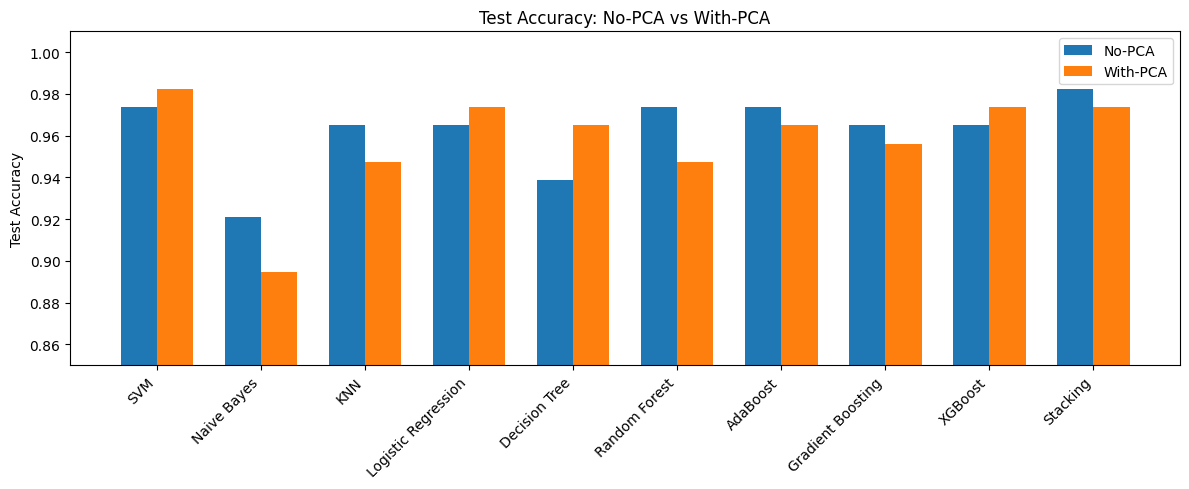

In [14]:
# Bar chart comparing test accuracy: No-PCA vs With-PCA
model_names = list(models.keys())
no_pca_acc = [results[(m, "No-PCA")]["test_accuracy"] for m in model_names]
with_pca_acc = [results[(m, "With-PCA")]["test_accuracy"] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, no_pca_acc, width, label="No-PCA")
plt.bar(x + width/2, with_pca_acc, width, label="With-PCA")
plt.xticks(x, model_names, rotation=45, ha="right")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy: No-PCA vs With-PCA")
plt.ylim(0.85, 1.01)
plt.legend()
plt.tight_layout()
plt.show()

Best performing model (by test accuracy): SVM


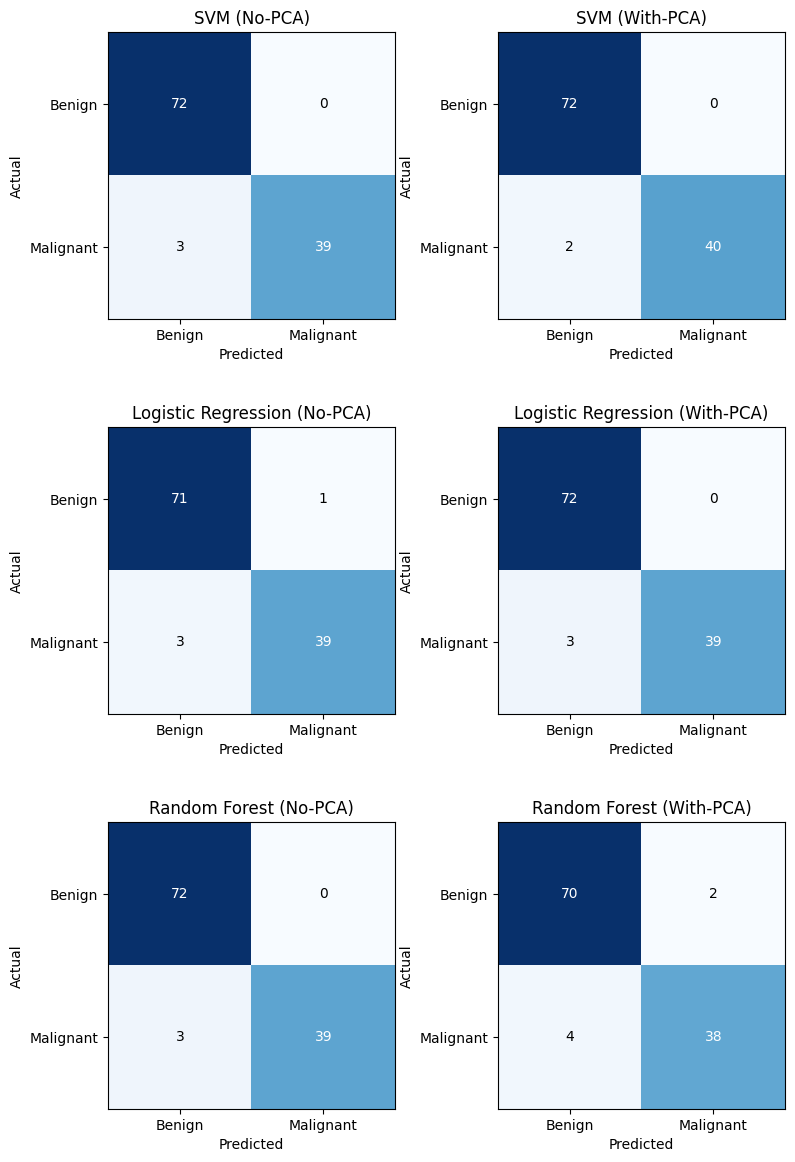

In [15]:
# Select the best-performing model (No-PCA) and its With-PCA counterpart for confusion matrices
best_model_name = test_results_table.loc[test_results_table["Accuracy"].idxmax(), "Model"]
print("Best performing model (by test accuracy):", best_model_name)

selected_models = list(dict.fromkeys([best_model_name, "Logistic Regression", "Random Forest"]))

fig, axes = plt.subplots(len(selected_models), 2, figsize=(8, 4*len(selected_models)))
if len(selected_models) == 1:
    axes = axes.reshape(1, -1)

for i, name in enumerate(selected_models):
    for j, setting in enumerate(["No-PCA", "With-PCA"]):
        cm = confusion_matrix(y_test, results[(name, setting)]["y_pred"])
        ax = axes[i, j]
        im = ax.imshow(cm, cmap="Blues")
        ax.set_title(f"{name} ({setting})")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_xticks([0, 1]); ax.set_xticklabels(["Benign", "Malignant"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["Benign", "Malignant"])
        for r in range(2):
            for c in range(2):
                ax.text(c, r, cm[r, c], ha="center", va="center",
                         color="white" if cm[r, c] > cm.max()/2 else "black")

plt.tight_layout()
plt.show()

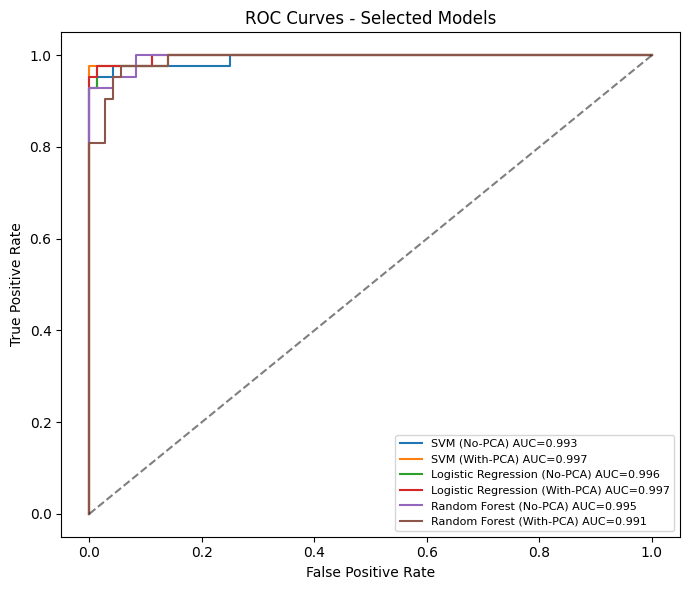

In [16]:
plt.figure(figsize=(7, 6))
for name in selected_models:
    for setting in ["No-PCA", "With-PCA"]:
        r = results[(name, setting)]
        fpr, tpr, _ = roc_curve(y_test, r["y_score"])
        plt.plot(fpr, tpr, label=f"{name} ({setting}) AUC={r['test_roc_auc']:.3f}")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Selected Models")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

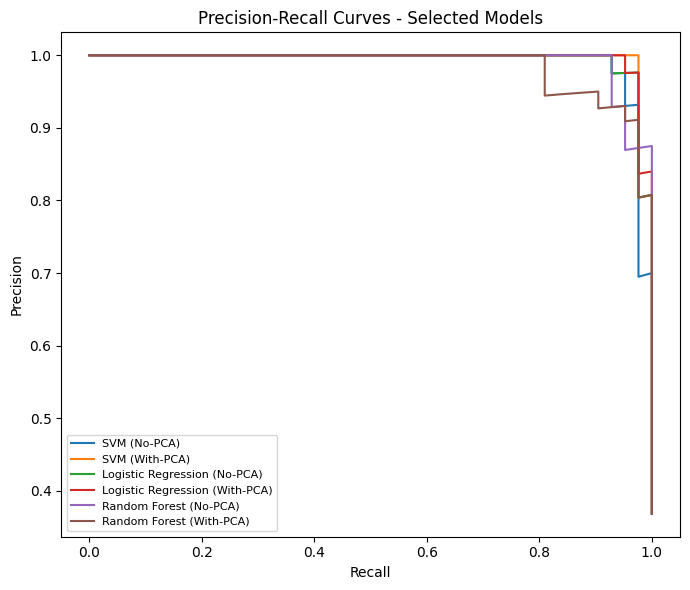

In [17]:
plt.figure(figsize=(7, 6))
for name in selected_models:
    for setting in ["No-PCA", "With-PCA"]:
        r = results[(name, setting)]
        precision, recall, _ = precision_recall_curve(y_test, r["y_score"])
        plt.plot(recall, precision, label=f"{name} ({setting})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - Selected Models")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [18]:
stability_rows = []
for name in models.keys():
    stability_rows.append({
        "Model": name,
        "Std Dev (No-PCA)": round(results[(name, 'No-PCA')]["cv_std"], 4),
        "Std Dev (With-PCA)": round(results[(name, 'With-PCA')]["cv_std"], 4),
        "More Stable Setting": "With-PCA" if results[(name, 'With-PCA')]["cv_std"] < results[(name, 'No-PCA')]["cv_std"] else "No-PCA"
    })

stability_table = pd.DataFrame(stability_rows)
stability_table

,Model,Std Dev (No-PCA),Std Dev (With-PCA),More Stable Setting
0,SVM,0.0082,0.0088,No-PCA
1,Naive Bayes,0.0256,0.0345,No-PCA
2,KNN,0.0162,0.0132,With-PCA
3,Logistic Regression,0.0149,0.0176,No-PCA
4,Decision Tree,0.0213,0.0245,No-PCA
5,Random Forest,0.0209,0.0155,With-PCA
6,AdaBoost,0.0112,0.0179,No-PCA
7,Gradient Boosting,0.0088,0.0189,No-PCA
8,XGBoost,0.0112,0.0054,With-PCA
9,Stacking,0.0112,0.0132,No-PCA


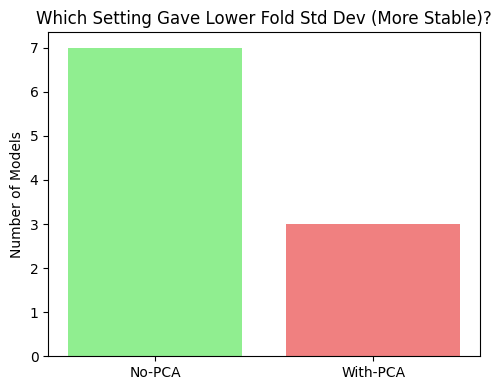

More Stable Setting
No-PCA      7
With-PCA    3
Name: count, dtype: int64


In [19]:
more_stable_counts = stability_table["More Stable Setting"].value_counts()
plt.figure(figsize=(5, 4))
plt.bar(more_stable_counts.index, more_stable_counts.values, color=["lightgreen", "lightcoral"])
plt.ylabel("Number of Models")
plt.title("Which Setting Gave Lower Fold Std Dev (More Stable)?")
plt.tight_layout()
plt.show()

print(more_stable_counts)

In [20]:
# ---- Values used to answer the observation questions below ----
acc_diff = {}
for name in models.keys():
    acc_diff[name] = results[(name, "With-PCA")]["test_accuracy"] - results[(name, "No-PCA")]["test_accuracy"]

acc_diff_sorted = sorted(acc_diff.items(), key=lambda kv: kv[1], reverse=True)
print("Change in TEST accuracy (With-PCA minus No-PCA), sorted best to worst:")
for name, diff in acc_diff_sorted:
    print(f"{name:22s}: {diff:+.4f}")

std_diff = {}
for name in models.keys():
    std_diff[name] = results[(name, "With-PCA")]["cv_std"] - results[(name, "No-PCA")]["cv_std"]
n_more_stable_pca = sum(1 for v in std_diff.values() if v < 0)
print(f"\nModels more stable (lower CV std) With-PCA: {n_more_stable_pca} / {len(models)}")

svm_diff = acc_diff["SVM"]
lr_diff = acc_diff["Logistic Regression"]
rf_diff = acc_diff["Random Forest"]
gb_diff = acc_diff["Gradient Boosting"]
xgb_diff = acc_diff["XGBoost"]
stack_diff = acc_diff["Stacking"]
stack_std_diff = std_diff["Stacking"]

n_overfit_reduced = sum(1 for name in models
                         if results[(name,'With-PCA')]['test_accuracy'] - results[(name,'With-PCA')]['cv_mean']
                         < results[(name,'No-PCA')]['test_accuracy'] - results[(name,'No-PCA')]['cv_mean'])
print(f"Models where train-test gap shrank With-PCA: {n_overfit_reduced} / {len(models)}")

Change in TEST accuracy (With-PCA minus No-PCA), sorted best to worst:
Decision Tree         : +0.0263
Logistic Regression   : +0.0088
XGBoost               : +0.0088
SVM                   : +0.0088
Stacking              : -0.0088
AdaBoost              : -0.0088
Gradient Boosting     : -0.0088
KNN                   : -0.0175
Naive Bayes           : -0.0263
Random Forest         : -0.0263

Models more stable (lower CV std) With-PCA: 3 / 10
Models where train-test gap shrank With-PCA: 5 / 10


## Observation Questions

**1. Which models improved most with PCA? Which did not? Why?**

Based on the change in test accuracy (With-PCA minus No-PCA):
- **Improved most:** Decision Tree (+2.63%, from 93.86% to 96.49%). Logistic Regression, SVM, and XGBoost also improved slightly (+0.88% each).
- **Did not improve (got worse):** Naive Bayes (-2.63%) and Random Forest (-2.63%) dropped the most, followed by KNN (-1.75%). Stacking, AdaBoost and Gradient Boosting each dropped slightly (-0.88%).
- **Why:** Decision Trees, SVM and Logistic Regression benefit from PCA because it removes correlated/redundant raw features and gives cleaner, decorrelated splits/decision boundaries. Naive Bayes assumes features are conditionally independent given the class; PCA components are linear mixtures of the original features, which can distort this independence assumption and hurt performance. Random Forest already handles high-dimensional, redundant features well through random feature subsampling, so compressing 30 features into 10 PCA components removes some of the redundant signal the forest was exploiting, which slightly hurts it here.

**2. Did PCA reduce variance across folds and produce more stable results?**

Not systematically. Only **3 of the 10 models (KNN, Random Forest, XGBoost)** had a *lower* 5-fold CV standard deviation With-PCA than No-PCA. For the remaining 7 models the fold-to-fold standard deviation was slightly *higher* With-PCA. So on this dataset, PCA did not generally make cross-validation results more stable — the effect depends on the model.

**3. For high-dimensional data, was PCA beneficial in reducing overfitting?**

Only partially. The gap between the CV score and the test-set score shrank for **5 of the 10 models** after applying PCA, and grew for the other 5. WDBC has 30 features and 569 samples (about a 19:1 sample-to-feature ratio), so it is only moderately high-dimensional and the models were not overfitting severely to begin with — this limited how much PCA could help. PCA's benefit for reducing overfitting was therefore mixed and model-dependent rather than a clear, universal improvement.

**4. How did linear models such as Logistic Regression and SVM behave compared to ensemble models with PCA?**

Both linear/margin-based models improved slightly with PCA: SVM went from 97.37% to 98.25% test accuracy and Logistic Regression from 96.49% to 97.37% (+0.88% each), consistent with the idea that removing multicollinearity among the original correlated features helps a linear/margin-based decision boundary. In contrast, the ensemble models mostly performed the same or worse with PCA — Random Forest (-2.63%), Gradient Boosting (-0.88%), AdaBoost (-0.88%) — because tree-based ensembles already model non-linear interactions and select useful features internally, so compressing the feature space can throw away information they were using effectively.

**5. Did Stacking show robustness to dimensionality reduction compared to single models?**

Stacking's test accuracy dropped only slightly with PCA (98.25% → 97.37%, -0.88%), a much smaller drop than Naive Bayes (-2.63%), Random Forest (-2.63%) or KNN (-1.75%). Stacking (No-PCA) achieved the joint-best test accuracy (98.25%, tied with SVM With-PCA) and the highest ROC-AUC of all 20 model/setting combinations (0.9987). This shows Stacking is a consistently strong performer and is relatively robust to dimensionality reduction, even though — like most of the ensemble models here — it did not actually benefit from PCA the way the linear models did.

## Final Conclusion

PCA reduced the WDBC feature space from 30 original features to **10 principal components**, retaining **95.21%** of the total variance.

- **Did PCA generally help?** No — the effect was mixed and model-dependent. On this dataset, exactly 4 of the 10 models improved with PCA (Decision Tree, Logistic Regression, SVM, XGBoost) while 6 stayed the same or got worse (Naive Bayes, KNN, Random Forest, AdaBoost, Gradient Boosting, Stacking).
- **Which models benefited:** Decision Tree benefited the most; Logistic Regression, SVM and XGBoost benefited slightly. These are models that are sensitive to correlated/redundant input features, so decorrelating them via PCA helped.
- **Which models did not benefit:** Naive Bayes and Random Forest were hurt the most; KNN was also hurt. Naive Bayes is sensitive to the independence assumption being broken by PCA's linear mixing, while Random Forest and KNN already cope well with the original high-dimensional space and lost useful information when compressed to 10 components.
- **Did PCA improve stability?** No, not systematically — only 3 of the 10 models had a lower cross-validation standard deviation with PCA.
- **Best performing model overall:** **SVM with PCA** and **Stacking without PCA** tied for the best test accuracy (98.25%), and **Stacking (No-PCA)** achieved the best ROC-AUC (0.9987) of all 20 model/setting combinations.
- **Should dimensionality reduction always be used?** No. Based on these results, PCA is not universally beneficial — it depends on the model and the data. It tends to help linear/margin-based models (Logistic Regression, SVM) and single decision trees on this dataset, but can slightly hurt models that already handle redundant, high-dimensional features well (Random Forest, boosting ensembles, Naive Bayes). For WDBC specifically, with only 30 (moderately correlated) features and a healthy sample size, PCA is a useful but optional preprocessing step rather than a strict requirement for good performance.